<a href="https://colab.research.google.com/github/1816x/Algoritmos-Aprendizaje-Automatico/blob/main/Practica_Tema_8_Pt_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#reto 1

# datos del reto
dist_propio = [2, 4]
dist_vecino = [3, 5, 7]
# escribe tu código para calcular a(i), b(i) y s(i)
a_i = sum(dist_propio) / len(dist_propio)
b_i = sum(dist_vecino) / len(dist_vecino)
s_i = (b_i - a_i) / max(a_i, b_i)
print(f"Silhouette Score para el punto P: {s_i:.2f}")

Silhouette Score para el punto P: 0.40


In [9]:
#reto 02
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
#reto: calcula y compara el silhouette_score para KMeans(k=4) y AgglomerativeClustering(k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X)
kmeans_silhouette = silhouette_score(X, kmeans_labels)
print(f"Silhouette Score para K-Means: {kmeans_silhouette:.4f}")

#genera un dataset sintético y aplica K-Means y Clustering Jerárquico.
agglomerative = AgglomerativeClustering(n_clusters=4)
agglomerative_labels = agglomerative.fit_predict(X)
agglomerative_silhouette = silhouette_score(X, agglomerative_labels)
print(f"Silhouette Score para Agglomerative Clustering: {agglomerative_silhouette:.4f}")

#calcula el Silhouette Score para ambos modelos y determina cuál obtuvo mejor puntuación general. Aplica K-Means
if kmeans_silhouette > agglomerative_silhouette:
    print(f"K-Means obtuvo un mejor Silhouette Score ({kmeans_silhouette:.4f}) que Agglomerative Clustering ({agglomerative_silhouette:.4f}).")
elif agglomerative_silhouette > kmeans_silhouette:
    print(f"Agglomerative Clustering obtuvo un mejor Silhouette Score ({agglomerative_silhouette:.4f}) que K-Means ({kmeans_silhouette:.4f}).")
else:
    print(f"Ambos algoritmos obtuvieron el mismo Silhouette Score ({kmeans_silhouette:.4f}).")



Silhouette Score para K-Means: 0.8335
Silhouette Score para Agglomerative Clustering: 0.8335
Ambos algoritmos obtuvieron el mismo Silhouette Score (0.8335).


Varianza explicada por componente: [0.30339538 0.27209967]


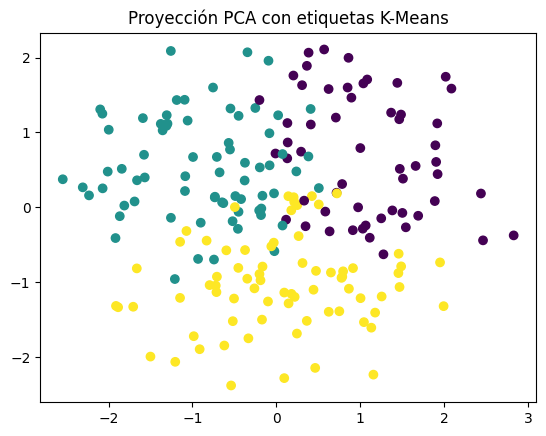

In [10]:
#reto 3

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.cluster import KMeans # import KMeans for clustering the new data
import matplotlib.pyplot as plt

# datos simulados con 4 variables
X_multi = np.random.rand(200, 4)
X_scaled = StandardScaler().fit_transform(X_multi)
# reto: Instancia PCA, ajusta sobre X_scaled e imprime explained_variance_ratio_
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)
print("Varianza explicada por componente:", pca.explained_variance_ratio_)

# perform K-Means on the new X_scaled data to generate consistent labels for visualization
kmeans_reto3 = KMeans(n_clusters=3, random_state=42, n_init='auto') # Using 3 clusters as an example for random data
labels_reto3 = kmeans_reto3.fit_predict(X_scaled)

# use the newly generated labels for plotting
plt.scatter(Z[:, 0], Z[:, 1], c=labels_reto3)
plt.title("Proyección PCA con etiquetas K-Means")
plt.show()

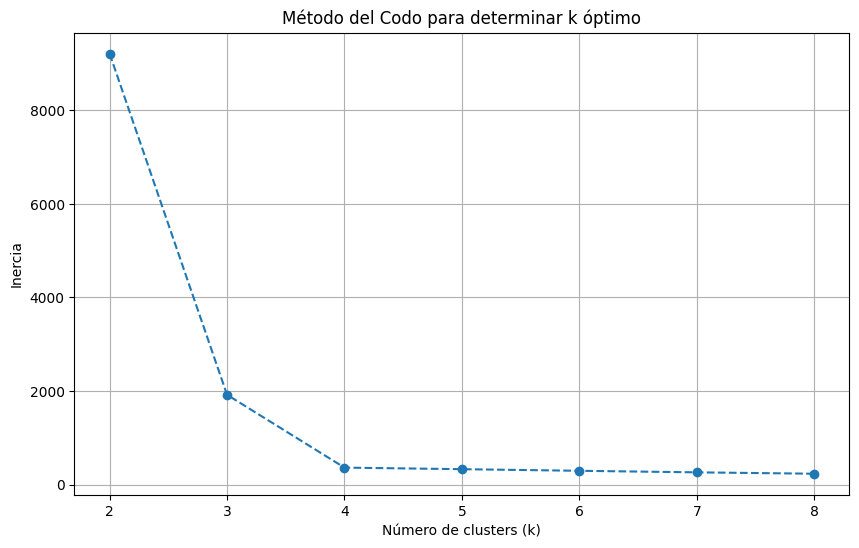

In [11]:
#reto 4
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# X es el dataset del reto 2

# lista para almacenar los valores de inercia
inercias = []

# rango de valores de k a probar
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

# graficar los resultados
fig = plt.figure(figsize=(10, 6))
plt.plot(k_range, inercias, marker='o', linestyle='--')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para determinar k óptimo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [12]:
#reto 5
import pandas as pd
# simulación de datos para el reto
df_mall = pd.DataFrame({
'Age': [19, 21, 20, 23, 31],
'Annual_Income': [15, 15, 16, 16, 17],
'Spending_Score': [39, 81, 6, 77, 40],
'Cluster': [0, 1, 0, 1, 2]
})
# reto: Agrupa por 'Cluster' y calcula la media de las variables numéricas
perfiles = df_mall.groupby('Cluster').mean()
print(perfiles)

          Age  Annual_Income  Spending_Score
Cluster                                     
0        19.5           15.5            22.5
1        22.0           15.5            79.0
2        31.0           17.0            40.0


In [13]:
from sklearn.cluster import KMeans

# features to use for clustering
X_mall = df_mall[['Age', 'Annual_Income', 'Spending_Score']]

# apply KMeans with k=5 (as suggested by the user)
kmeans_optimal = KMeans(n_clusters=5, random_state=42, n_init='auto')
df_mall['New_Cluster'] = kmeans_optimal.fit_predict(X_mall)

print("DataFrame con nuevas etiquetas de cluster:")
display(df_mall.head())

DataFrame con nuevas etiquetas de cluster:


,Age,Annual_Income,Spending_Score,Cluster,New_Cluster
0,19,15,39,0,3
1,21,15,81,1,0
2,20,16,6,0,2
3,23,16,77,1,4
4,31,17,40,2,1


In [14]:
# agrupar por las nuevas etiquetas de 'New_Cluster' y calcular la media de las variables clave
perfiles_nuevos = df_mall.groupby('New_Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean()

print("Perfiles de cluster para definir estrategias comerciales:")
display(perfiles_nuevos)

Perfiles de cluster para definir estrategias comerciales:


,Age,Annual_Income,Spending_Score
New_Cluster,,,
0,21.0,15.0,81.0
1,31.0,17.0,40.0
2,20.0,16.0,6.0
3,19.0,15.0,39.0
4,23.0,16.0,77.0
